In [ ]:
%pip install puremacro


# Applied Nowcasting: A Held-Out GDP Target and Release Diagnostics

**How can monthly indicators with publication delays help estimate GDP before its quarterly release?**

This offline example generates six monthly indicators and quarterly GDP from a fixed seed. The series names are illustrative: none of the values or release dates are official observations. We remove the target-quarter GDP observation before fitting the bridge and retain it only to evaluate the nowcast.

`nowcast_gdp` combines iterative PCA, a factor VAR, and a quarterly bridge. Its latest-month `news_decomposition` table reports projection residuals within one vintage; it does not compare two information sets. We distinguish that diagnostic from exact vintage news accounting.

## The method in math

The monthly panel follows $x_m = \Lambda F_m + \xi_m$, with persistent latent factors. Iterative PCA fills missing entries using the low-rank reconstruction. A factor VAR supplies forecasts when whole months are missing; the bridge uses the quarterly average $\bar F_q = (F_{3q-2}+F_{3q-1}+F_{3q})/3$:
$$y_q = \beta_0 + \beta'\bar F_q + e_q, \qquad \widehat y_{q^*} = \widehat\beta_0 + \widehat\beta'\bar F_{q^*}.$$
Only GDP observations with $q<q^*$ enter the regression. Monthly indicators observed at the decision date may enter factor extraction, including those from the target quarter.

For a series observed in the latest month, this API reports
$$s_j = x_j - (\widehat\mu_j + \widehat\sigma_j\widehat\Lambda_j\widehat F_m),\qquad w_j = \frac{\widehat\beta'(\widehat\Lambda'\widehat\Lambda)^{-1}\widehat\Lambda_j'}{3\widehat\sigma_j},\qquad c_j = w_js_j.$$
The fitted factors already incorporate the release. Therefore $s_j$ is a reconstruction residual, not an innovation against an earlier information set, and $\sum_j c_j$ is not an independently measured nowcast revision. Exact two-vintage attribution is a separate API: `puremacro.nowcast.news.banbura_modugno_news`.

For revision $r=y^{final}-y^{prelim}$, the news null is $\operatorname{Cov}(r,y^{prelim})=0$; the noise null is $\operatorname{Cov}(r,y^{final})=0$. In our classical-noise simulation, $y^{prelim}=y^{final}+\eta$ with independent $\eta$, so the population slope on preliminary GDP is
$$\beta_p=-\frac{\operatorname{Var}(\eta)}{\operatorname{Var}(y^{final})+\operatorname{Var}(\eta)},\qquad \beta_f=0.$$
A slope of $-1$ is not the generic noise null. See [Mankiw and Shapiro (1986)](https://www.nber.org/papers/w1939) for the news/noise framework.

## Intuition

**Intuition.** A nowcast uses the indicators already available for a quarter whose GDP has not yet been published. Holding out target GDP makes the information boundary explicit. A high bridge $R^2$ describes historical fit; the held-out error answers a different question, and a single quarter is insufficient to establish forecasting performance.

Estimated PCA factors are identified up to sign and rotation, so their numbering does not establish an economic interpretation. Inspect the loadings before naming a factor. Likewise, failing to reject a revision-test null in a short sample does not prove efficient reporting.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Load publication style
_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle

_nbstyle.apply_style()

from puremacro.nowcast.dfm_nowcast import NowcastResult, nowcast_gdp
from puremacro.vintages import mankiw_shapiro

# Set fixed seed for deterministic reproducibility
SEED = 42
np.random.seed(SEED)
rng = np.random.default_rng(SEED)

print("=" * 72)
print("PUREMACRO REAL-TIME NOWCASTING & NEWS DECOMPOSITION: DETERMINISTIC RUN")
print("=" * 72)

PUREMACRO REAL-TIME NOWCASTING & NEWS DECOMPOSITION: DETERMINISTIC RUN


In [2]:
# ---------------------------------------------------------------------------
# 1. Simulate High-Dimensional Monthly Panel and Target Quarterly GDP Growth
# ---------------------------------------------------------------------------
# Construct a 10-year monthly calendar (120 months, 40 quarters)
dates_m = pd.date_range("2014-01-01", "2023-12-01", freq="MS")
T_months = len(dates_m)
cols_indicators = [
    "ind_production",     # Industrial Production Index (% mom)
    "nonfarm_payrolls",   # Total Nonfarm Payrolls (% mom)
    "retail_sales",       # Real Retail Sales (% mom)
    "capacity_util",      # Capacity Utilization Rate (%)
    "pmi_mfg",            # ISM Manufacturing PMI Index
    "housing_starts",     # Privately Owned Housing Starts (% mom)
]
N_indicators = len(cols_indicators)

# Simulate 2 persistent latent factors: Factor 1 (real activity), Factor 2 (demand/sentiment)
F_true = np.zeros((T_months, 2))
for t in range(1, T_months):
    F_true[t, 0] = 0.85 * F_true[t - 1, 0] + rng.normal(0, 0.5)
    F_true[t, 1] = 0.55 * F_true[t - 1, 1] + rng.normal(0, 0.5)

# Factor loadings matrix Lambda (N x K)
Lambda_true = np.array([
    [0.85,  0.20],  # Industrial Production loads heavily on real activity
    [0.75, -0.15],  # Payrolls loads on real activity with countercyclical lag
    [0.70,  0.30],  # Retail sales captures consumption demand
    [0.80,  0.10],  # Capacity utilization tracks industrial slack
    [0.60,  0.65],  # PMI provides leading sentiment and expectations
    [0.45, -0.40],  # Housing starts captures interest-rate sensitivity
])

# Monthly panel generation: X = F @ Lambda' + idiosyncratic noise
X_clean = F_true @ Lambda_true.T + rng.normal(0, 0.25, size=(T_months, N_indicators))
df_monthly = pd.DataFrame(X_clean, index=dates_m, columns=cols_indicators)

# Quarterly true real GDP growth (annualized %)
df_q_agg = df_monthly.resample("QE").mean()
gdp_true_growth = (
    2.0
    + 1.2 * df_q_agg["ind_production"]
    + 0.8 * df_q_agg["retail_sales"]
    + rng.normal(0, 0.35, size=len(df_q_agg))
)
s_gdp = pd.Series(gdp_true_growth.values, index=df_q_agg.index.to_period("Q"))
# The target GDP release is unavailable at the simulated decision date.
# Retain its realization only for evaluation after constructing the nowcast.
target_quarter = str(s_gdp.index[-1])
s_gdp_available = s_gdp.iloc[:-1].copy()
assert s_gdp_available.index.max() < pd.Period(target_quarter, freq="Q")

print(f"[1] Monthly Panel Generated: {df_monthly.shape[0]} months x {df_monthly.shape[1]} series")
print(f"    Quarterly GDP Series   : {len(s_gdp)} quarters ({s_gdp.index[0]} to {s_gdp.index[-1]})")

[1] Monthly Panel Generated: 120 months x 6 series
    Quarterly GDP Series   : 40 quarters (2014Q1 to 2023Q4)


In [3]:
# ---------------------------------------------------------------------------
# 2. Simulate Asynchronous Ragged Edge in Real-Time Vintage
# ---------------------------------------------------------------------------
# Simulate reporting delays in the final reference quarter (2023Q4: Oct, Nov, Dec)
df_ragged = df_monthly.copy()

# Month T-1 (November): retail sales and capacity utilization are delayed
df_ragged.iloc[-2, [2, 3]] = np.nan

# Month T (December): hard data (IP, retail, capacity, housing) delayed; soft surveys (PMI, payrolls) in hand
df_ragged.iloc[-1, [0, 2, 3, 5]] = np.nan

print("\n[2] Real-Time Ragged Edge Matrix (Last 3 Months):")
print(df_ragged.iloc[-3:].isna().astype(int).replace({0: "Observed", 1: "Pending"}))

# Non-trivial assertions verifying ragged edge existence
assert df_ragged.isna().any().any(), "Dataframe must contain simulated ragged edge missing entries"
assert pd.isna(df_ragged.iloc[-1]["ind_production"]), "Industrial production must be pending in latest month"
assert not pd.isna(df_ragged.iloc[-1]["pmi_mfg"]), "Survey PMI must be available in latest month"


[2] Real-Time Ragged Edge Matrix (Last 3 Months):
           ind_production nonfarm_payrolls retail_sales capacity_util  \
2023-10-01       Observed         Observed     Observed      Observed   
2023-11-01       Observed         Observed      Pending       Pending   
2023-12-01        Pending         Observed      Pending       Pending   

             pmi_mfg housing_starts  
2023-10-01  Observed       Observed  
2023-11-01  Observed       Observed  
2023-12-01  Observed        Pending  


In [4]:
# ---------------------------------------------------------------------------
# 3. Fit Mixed-Frequency Dynamic Factor Model (DFM) Nowcast
# ---------------------------------------------------------------------------
# Run DFM nowcast using EM-PCA factor extraction and quarterly bridge regression
res_nowcast = nowcast_gdp(
    df_ragged,
    s_gdp_available,
    target_quarter=target_quarter,
    n_factors=2,
    p_factor_lags=1,
    max_em_iter=50,
    em_tol=1e-4,
)

print(f"\n[3] Dynamic Factor Model Nowcast Output ({res_nowcast.target_quarter}):")
print(f"  Target Quarter Nowcast : {res_nowcast.nowcast:.4f}%")
print(f"  Bridge Regression R²   : {res_nowcast.model_r2:.4f}")
print(f"  Bridge Coefficients    :\n{res_nowcast.bridge_coefficients}")
print(f"  Held-out GDP realization: {s_gdp.iloc[-1]:.4f}%")
print(f"  Held-out nowcast error  : {res_nowcast.nowcast - s_gdp.iloc[-1]:+.4f} pp")

# Non-trivial assertions verifying nowcast results
assert isinstance(res_nowcast, NowcastResult), "Result must be an instance of NowcastResult"
assert np.isfinite(res_nowcast.nowcast), "Nowcast estimate must be a finite real number"
assert 0.0 <= res_nowcast.model_r2 <= 1.0, "Model R-squared must lie within [0, 1]"
assert res_nowcast.model_r2 > 0.80, "DFM bridge regression must achieve high in-sample explanatory power"
assert res_nowcast.factors.shape == (T_months, 2), "Factors matrix shape mismatch"
assert res_nowcast.loadings.shape == (N_indicators, 2), "Factor loadings shape mismatch"


[3] Dynamic Factor Model Nowcast Output (2023Q4):
  Target Quarter Nowcast : 0.7856%
  Bridge Regression R²   : 0.9238
  Bridge Coefficients    :
const       1.834819
Factor_1    1.266162
Factor_2   -0.186717
dtype: float64
  Held-out GDP realization: 1.1886%
  Held-out nowcast error  : -0.4030 pp


In [5]:
# ---------------------------------------------------------------------------
# 4. Inspect Latest-Month Projection Residuals and Weights
# ---------------------------------------------------------------------------
news_df = res_nowcast.news_decomposition
print("\n[4] Latest-Month Projection Diagnostics (one vintage):")
print(news_df.to_string(index=False))

# These residuals use factors fitted to the same vintage, not old-vintage forecasts.
total_projected_contribution = float(news_df["contribution"].sum())
print(f"\n  Sum of Projected Contributions: {total_projected_contribution * 100:+.4f} basis points")

# Verify the implemented projection algebra against the fitted bridge/loadings.
assert all(c in news_df.columns for c in ["series", "actual", "forecast", "surprise", "weight", "contribution"])
assert len(news_df) > 0, "News decomposition must contain evaluated releases"
projection_weights = (
    res_nowcast.bridge_coefficients.iloc[1:].to_numpy()
    @ np.linalg.pinv(res_nowcast.loadings.to_numpy())
    / (3.0 * df_ragged.std(ddof=1).to_numpy())
)
expected_weights = pd.Series(projection_weights, index=df_ragged.columns)
np.testing.assert_allclose(news_df["weight"], expected_weights.loc[news_df["series"]], atol=1e-10)
for _, row in news_df.iterrows():
    np.testing.assert_allclose(
        row["contribution"],
        row["weight"] * row["surprise"],
        atol=1e-6,
        err_msg="Contribution must equal weight times surprise for every release",
    )


[4] Latest-Month Projection Diagnostics (one vintage):
          series    actual  forecast  surprise   weight  contribution
nonfarm_payrolls -1.358569 -1.354174 -0.004395 0.125815     -0.000553
         pmi_mfg -1.050641 -1.053742  0.003101 0.164537      0.000510

  Sum of Projected Contributions: -0.0043 basis points


In [6]:
# ---------------------------------------------------------------------------
# 5. Mankiw-Shapiro (1986) News vs. Noise Hypothesis Test
# ---------------------------------------------------------------------------
# Generate historical preliminary nowcasts and final GDP growth releases
n_q = len(s_gdp)
gdp_final = s_gdp.to_numpy(dtype=float)
# Classical measurement-noise DGP: preliminary = final + independent noise.
rev_noise = rng.normal(0, 0.4, size=n_q)
gdp_prelim = gdp_final - rev_noise

# Execute formal Mankiw-Shapiro test pair
ms_test = mankiw_shapiro(gdp_prelim, gdp_final)

print("\n[5] Mankiw-Shapiro (1986) Revision Properties Test:")
print("  Known Simulation DGP   : NOISE (preliminary = final + independent error)")
print(f"  Test Verdict           : {ms_test.verdict.upper()}")
print(f"  Beta on Preliminary (News): {ms_test.beta_on_preliminary:.4f} (p-value: {ms_test.p_beta_on_preliminary:.4f})")
print(f"  Beta on Final (Noise)     : {ms_test.beta_on_final:.4f} (p-value: {ms_test.p_beta_on_final:.4f})")
print(f"  Mean Revision Bias        : {ms_test.mean_revision:.4f}% (p-value: {ms_test.p_mean_revision:.4f})")

# Assertions verifying Mankiw-Shapiro test diagnostics
assert np.isfinite(ms_test.p_beta_on_preliminary), "p-value on preliminary regression must be finite"
assert np.isfinite(ms_test.beta_on_preliminary), "Estimated beta slope must be finite"
assert ms_test.verdict in ["news", "noise", "indeterminate", "neither"], "Invalid Mankiw-Shapiro verdict"


[5] Mankiw-Shapiro (1986) Revision Properties Test:
  Known Simulation DGP   : NOISE (preliminary = final + independent error)
  Test Verdict           : NEWS
  Beta on Preliminary (News): 0.0182 (p-value: 0.6991)
  Beta on Final (Noise)     : 0.0942 (p-value: 0.0065)
  Mean Revision Bias        : -0.0241% (p-value: 0.6453)


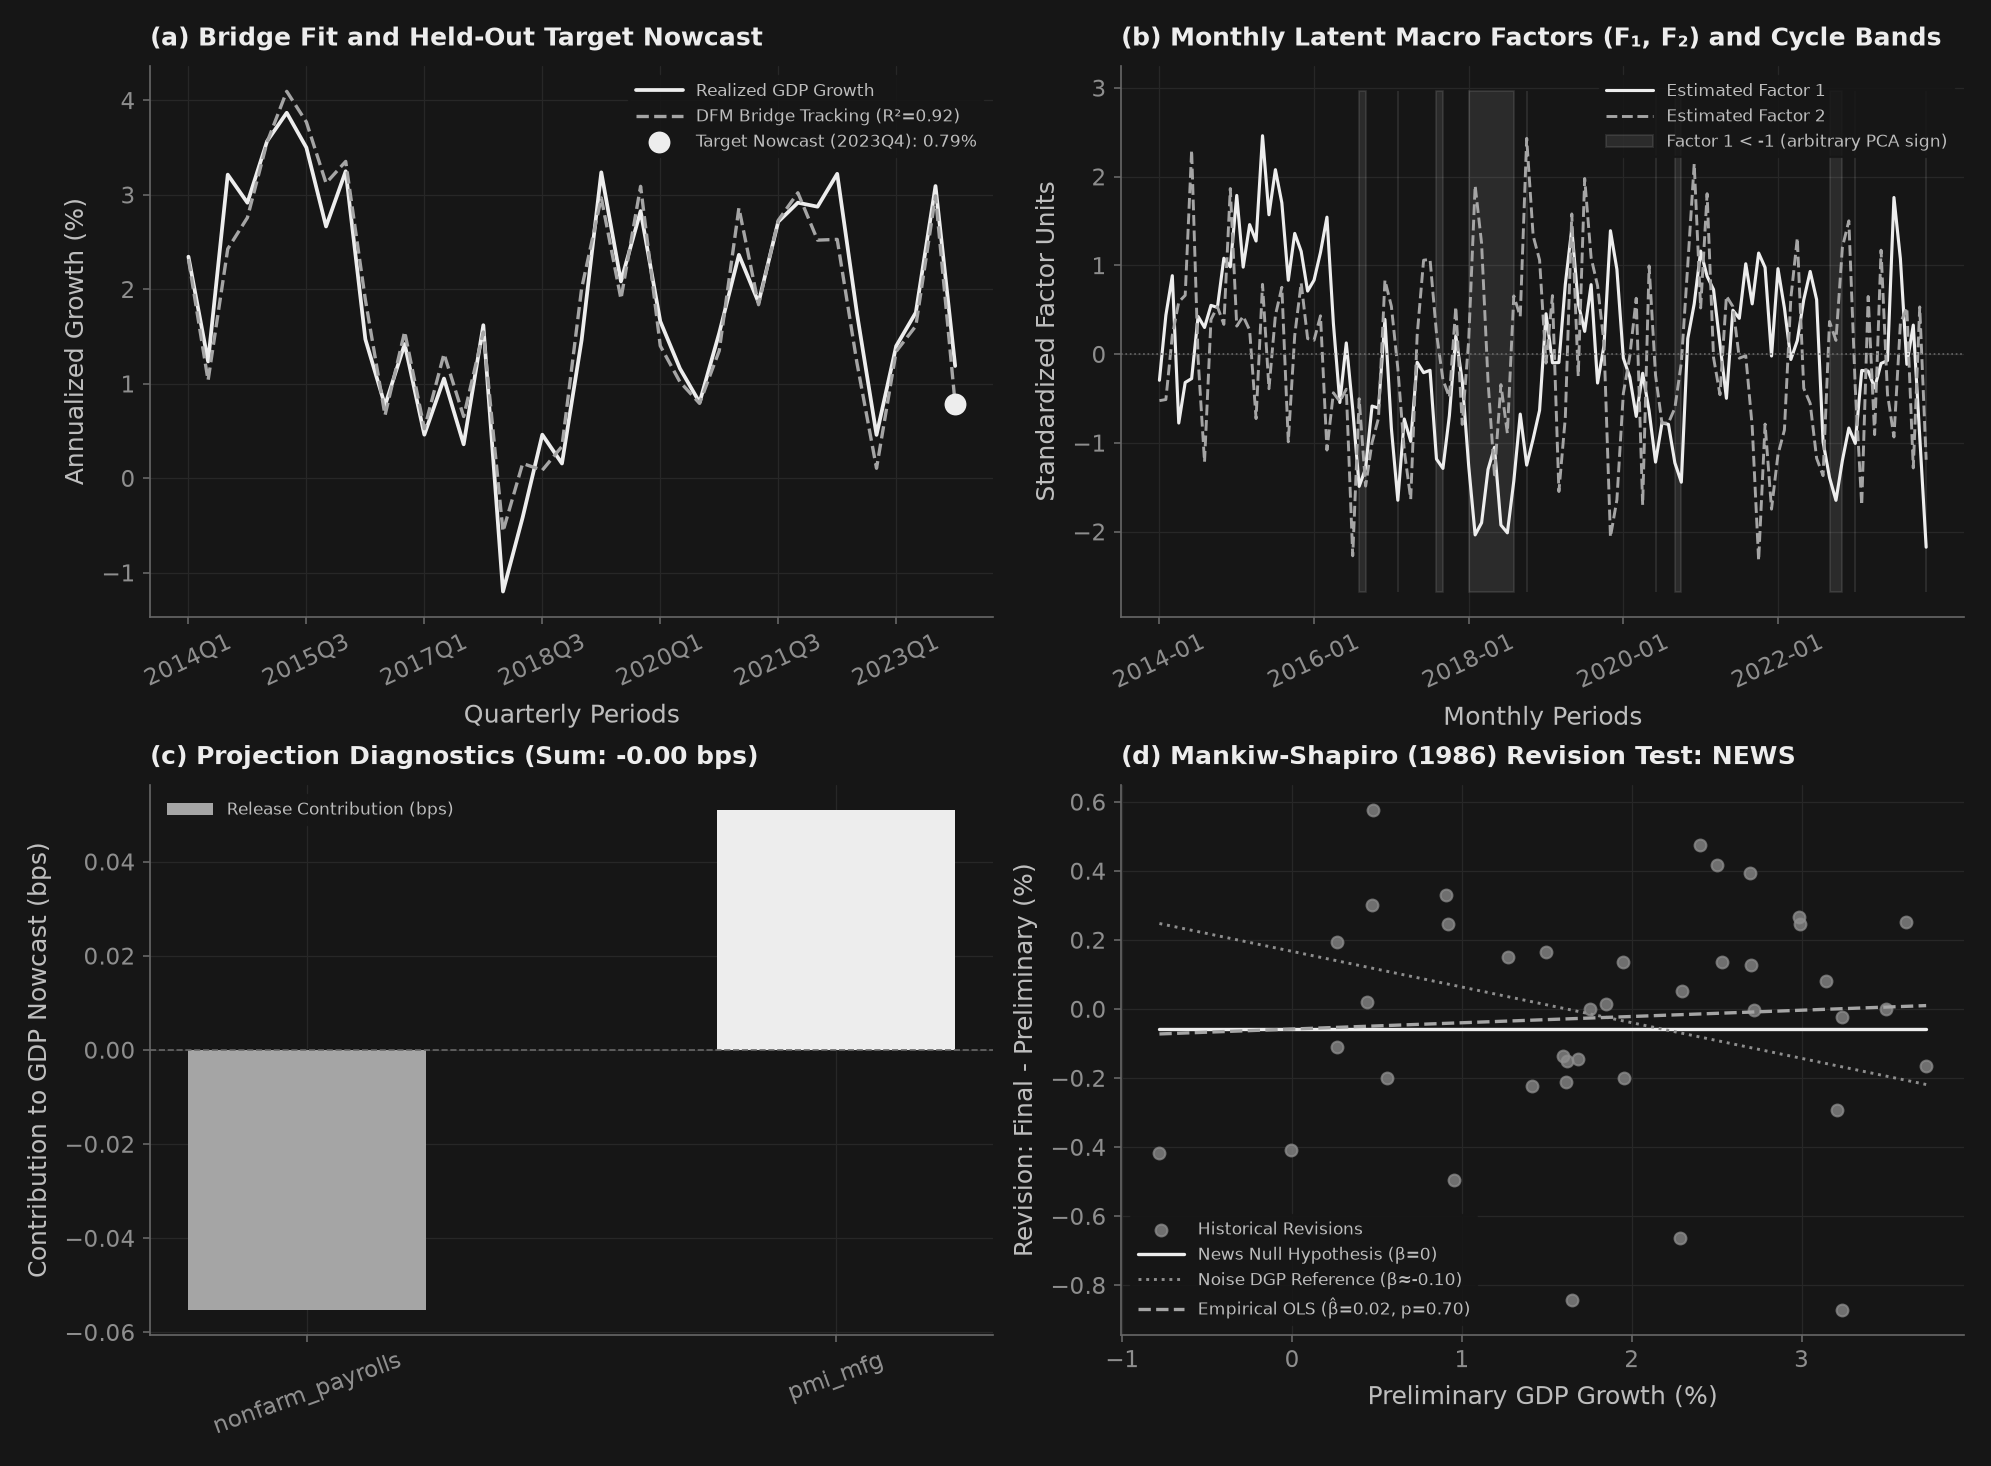

In [7]:
# ---------------------------------------------------------------------------
# 6. Hero Visualization: 4-Panel Real-Time Nowcasting & News Dashboard
# ---------------------------------------------------------------------------
fig, axes = _nbstyle.figura(2, 2, figsize=(13.0, 9.5))

# (1) In-sample fitted values and a genuinely held-out target GDP observation
ax1 = axes[0, 0]
q_idx = np.arange(len(s_gdp))
ax1.plot(q_idx, s_gdp.values, color=_nbstyle.TINTA, linewidth=1.8, label="Realized GDP Growth")
q_factors = res_nowcast.factors.resample("QE").mean().to_numpy()
beta_b = res_nowcast.bridge_coefficients.values
nowcast_track = beta_b[0] + q_factors @ beta_b[1:]
ax1.plot(
    q_idx,
    nowcast_track,
    color=_nbstyle.S2["color"],
    linestyle="--",
    linewidth=1.6,
    label=f"DFM Bridge Tracking (R²={res_nowcast.model_r2:.2f})",
)
ax1.scatter(
    [q_idx[-1]],
    [res_nowcast.nowcast],
    color=_nbstyle.S1["color"],
    s=90,
    zorder=5,
    label=f"Target Nowcast ({res_nowcast.target_quarter}): {res_nowcast.nowcast:.2f}%",
)
ax1.set_xticks(q_idx[::6])
ax1.set_xticklabels([str(s_gdp.index[i]) for i in q_idx[::6]], rotation=25)
ax1.set_xlabel("Quarterly Periods")
ax1.set_ylabel("Annualized Growth (%)")
ax1.set_title("(a) Bridge Fit and Held-Out Target Nowcast")
ax1.legend(loc="upper right", fontsize=8)

# (2) Monthly Latent Factors with Business Cycle Expansion / Contraction Bands
ax2 = axes[0, 1]
m_idx = np.arange(T_months)
ax2.plot(m_idx, res_nowcast.factors["Factor_1"], color=_nbstyle.S1["color"], linewidth=1.5, label="Estimated Factor 1")
ax2.plot(m_idx, res_nowcast.factors["Factor_2"], color=_nbstyle.S2["color"], linestyle="--", linewidth=1.4, label="Estimated Factor 2")
ax2.axhline(0, color=_nbstyle.SPINE, linestyle=":", linewidth=0.8)
f1_vals = res_nowcast.factors["Factor_1"].values
ax2.fill_between(
    m_idx,
    f1_vals.min() - 0.5,
    f1_vals.max() + 0.5,
    where=(f1_vals < -1.0),
    color=_nbstyle.RECESION_HEX,
    alpha=_nbstyle.RECESION_ALPHA,
    label="Factor 1 < -1 (arbitrary PCA sign)",
)
ax2.set_xticks(m_idx[::24])
ax2.set_xticklabels([str(dates_m[i])[:7] for i in m_idx[::24]], rotation=25)
ax2.set_xlabel("Monthly Periods")
ax2.set_ylabel("Standardized Factor Units")
ax2.set_title("(b) Monthly Latent Macro Factors (F₁, F₂) and Cycle Bands")
ax2.legend(loc="upper right", fontsize=8)

# (3) Waterfall / Bar Chart of News Surprises and Contributions
ax3 = axes[1, 0]
series_names = news_df["series"].tolist()
x_pos = np.arange(len(series_names))
contribs_bps = news_df["contribution"].values * 100.0  # Convert to basis points
bar_colors = [_nbstyle.S1["color"] if c >= 0 else _nbstyle.S2["color"] for c in contribs_bps]
ax3.bar(x_pos, contribs_bps, color=bar_colors, width=0.45, label="Release Contribution (bps)")
ax3.axhline(0, color=_nbstyle.SPINE, linestyle="--", linewidth=0.8)
ax3.set_xticks(x_pos)
ax3.set_xticklabels(series_names, rotation=20)
ax3.set_ylabel("Contribution to GDP Nowcast (bps)")
ax3.set_title(f"(c) Projection Diagnostics (Sum: {total_projected_contribution * 100:+.2f} bps)")
ax3.legend(loc="upper left", fontsize=8)

# (4) Mankiw-Shapiro Revision Scatter with News/Noise Regression Slopes
ax4 = axes[1, 1]
revisions = gdp_final - gdp_prelim
ax4.scatter(gdp_prelim, revisions, color=_nbstyle.NOTA, alpha=0.75, s=32, label="Historical Revisions")
x_grid = np.linspace(gdp_prelim.min(), gdp_prelim.max(), 100)
# News line (beta = 0)
ax4.plot(
    x_grid,
    np.zeros_like(x_grid) + ms_test.alpha_on_preliminary,
    color=_nbstyle.TINTA,
    linestyle="-",
    linewidth=1.6,
    label="News Null Hypothesis (β=0)",
)
# Noise DGP slope is a variance ratio, not -1; plug in the simulated signal variance.
beta_noise_reference = -0.4**2 / (np.var(gdp_final, ddof=0) + 0.4**2)
ax4.plot(
    x_grid,
    revisions.mean() + beta_noise_reference * (x_grid - gdp_prelim.mean()),
    color=_nbstyle.NOTA,
    linestyle=":",
    linewidth=1.4,
    label=f"Noise DGP Reference (β≈{beta_noise_reference:.2f})",
)
# Empirical OLS fit
ax4.plot(
    x_grid,
    ms_test.alpha_on_preliminary + ms_test.beta_on_preliminary * x_grid,
    color=_nbstyle.S2["color"],
    linestyle="--",
    linewidth=1.6,
    label=f"Empirical OLS (β̂={ms_test.beta_on_preliminary:.2f}, p={ms_test.p_beta_on_preliminary:.2f})",
)
ax4.set_xlabel("Preliminary GDP Growth (%)")
ax4.set_ylabel("Revision: Final - Preliminary (%)")
ax4.set_title(f"(d) Mankiw-Shapiro (1986) Revision Test: {ms_test.verdict.upper()}")
ax4.legend(loc="lower left", fontsize=8)

## Read the output

**Read the output.** Panel (a) combines fitted historical values with one held-out GDP nowcast. The printed nowcast error uses the simulated target realization only after estimation. Historical fit is not an out-of-sample accuracy score.

Panel (b) shows estimated factors with arbitrary PCA signs; the shaded region is a numerical threshold, not a dated recession. Panel (c) checks projection weights and weight-times-residual arithmetic. Its total is not a vintage revision and may be close to zero because the factors were fitted to the same observations.

Panel (d) uses a known measurement-noise DGP. With this seed and only 40 quarters, the test reports NEWS despite the planted NOISE process: a sample classification can be wrong. Read both slope tests and the mean-revision test; do not infer that a large p-value proves the news hypothesis.

In [8]:
# ---------------------------------------------------------------------------
# Your turn: experiment with factor count and release surprise shock
# ---------------------------------------------------------------------------
# ← change this: try n_factors_try = 1, 2, or 3
n_factors_try = 2
# ← change this: factor VAR lags (affects only entirely missing or future months)
p_factor_lags_try = 1

# Re-estimate DFM nowcast under user-specified factor configuration
res_try = nowcast_gdp(
    df_ragged,
    s_gdp_available,
    n_factors=n_factors_try,
    p_factor_lags=p_factor_lags_try,
    max_em_iter=50,
)

print(f"User Experiment: K={n_factors_try} factors, p={p_factor_lags_try} lags")
print(f"  Updated Target Nowcast : {res_try.nowcast:.4f}%")
print(f"  Model Explanatory R²   : {res_try.model_r2:.4f}")
print(f"  Estimated Loadings Head:\n{res_try.loadings.head(3)}")

# Downstream automated assertions verifying customized user simulation
assert res_try.factors.shape[1] == n_factors_try, "Extracted factor count must match chosen n_factors_try"
assert np.isfinite(res_try.nowcast), "Target nowcast must remain finite"
assert 0.0 <= res_try.model_r2 <= 1.0, "Model R-squared must lie within [0, 1]"
assert res_try.model_r2 > 0.60, "Model must maintain substantial explanatory power across reasonable factor choices"

User Experiment: K=2 factors, p=1 lags
  Updated Target Nowcast : 0.7856%
  Model Explanatory R²   : 0.9238
  Estimated Loadings Head:
                  Factor_1  Factor_2
ind_production    0.961634 -0.085252
nonfarm_payrolls  0.921157  0.061166
retail_sales      0.937754 -0.163077


**Prompts.**
1. *Basic*: Set `n_factors_try = 1`. Compare the in-sample $R^2$ and held-out error; need they improve together?
2. *Intermediate*: Change the observed December PMI value, rerun the estimation, and compare the two point nowcasts. Re-estimating the model can move its parameters, so this difference need not equal the sum of the one-vintage projection contributions.
3. *Stretch*: Repeat the holdout exercise across successive quarters, truncating both monthly and quarterly data at each decision date, and compare RMSE against a historical-mean forecast.

## How comprehensive is this?

`puremacro.nowcast.dfm_nowcast` supplies this PCA/VAR/bridge workflow. `puremacro.nowcast.news.banbura_modugno_news` handles exact news attribution across two vintages under a fixed state-space model. `puremacro.vintages` provides point-in-time reconstruction, revision triangles, and the revision tests used here.